
# Clase 8 — Calidad y limpieza de datos (Ames Housing)

**Objetivos de la clase**
- Comprender y aplicar los conceptos de **completitud, consistencia y fiabilidad**.
- Identificar **errores y duplicados**.
- Realizar **normalización y validación de formatos**.
- Documentar decisiones de limpieza y su impacto.

**Dataset**: Ames Housing (Kaggle)

El dataset de Ames Housing recopila información detallada de viviendas vendidas en Ames, Iowa. Para esta clase usaremos un subconjunto reducido de 12 columnas.

- SalePrice: precio de venta de la vivienda (numérica, continua).
- LotArea: superficie total del lote en pies cuadrados (numérica).
- LotFrontage: longitud en pies de la fachada que da a la calle (numérica, con valores faltantes).
- Neighborhood: vecindario donde se ubica la propiedad (categórica).
- MSSubClass: tipo de vivienda, codificado numéricamente pero que debe tratarse como categoría.
- YearBuilt: año de construcción original de la casa (numérica).
- YearRemodAdd: año de la última remodelación o adición (numérica).
- YrSold: año en que la propiedad fue vendida (numérica, puede transformarse en fecha).
- GarageCars: número de autos que caben en el garage (numérica discreta).
- GarageArea: superficie del garage en pies cuadrados (numérica).
- Alley: tipo de calle de acceso a la vivienda (categórica, con muchos valores faltantes).
- FireplaceQu: calidad de la chimenea (categórica, también con valores faltantes).

## 1) Setup y presentación del dataset

In [5]:
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

CSV_PATH = "AmesHousing.csv"
df_raw = pd.read_csv(CSV_PATH)

## 2) Subconjunto de columnas para la clase

Crea el data frame seleccionando sólo las columnas solicitadas

In [4]:
cols = [
    "SalePrice","Lot Area","Lot Frontage","Neighborhood","MS SubClass",
    "Year Built","Year Remod/Add","Yr Sold","Garage Cars","Garage Area","Alley","Fireplace Qu"
]

df = df_raw[cols]

df

,SalePrice,Lot Area,Lot Frontage,Neighborhood,MS SubClass,Year Built,Year Remod/Add,Yr Sold,Garage Cars,Garage Area,Alley,Fireplace Qu
0,215000,31770,141.0,NAmes,20,1960,1960,2010,2.0,528.0,NaN,Gd
1,105000,11622,80.0,NAmes,20,1961,1961,2010,1.0,730.0,NaN,NaN
2,172000,14267,81.0,NAmes,20,1958,1958,2010,1.0,312.0,NaN,NaN
3,244000,11160,93.0,NAmes,20,1968,1968,2010,2.0,522.0,NaN,TA
4,189900,13830,74.0,Gilbert,60,1997,1998,2010,2.0,482.0,NaN,TA
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,142500,7937,37.0,Mitchel,80,1984,1984,2006,2.0,588.0,NaN,NaN
2926,131000,8885,NaN,Mitchel,20,1983,1983,2006,2.0,484.0,NaN,NaN
2927,132000,10441,62.0,Mitchel,85,1992,1992,2006,0.0,0.0,NaN,NaN
2928,170000,10010,77.0,Mitchel,20,1974,1975,2006,2.0,418.0,NaN,TA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SalePrice       2930 non-null   int64  
 1   Lot Area        2930 non-null   int64  
 2   Lot Frontage    2440 non-null   float64
 3   Neighborhood    2930 non-null   object 
 4   MS SubClass     2930 non-null   int64  
 5   Year Built      2930 non-null   int64  
 6   Year Remod/Add  2930 non-null   int64  
 7   Yr Sold         2930 non-null   int64  
 8   Garage Cars     2929 non-null   float64
 9   Garage Area     2929 non-null   float64
 10  Alley           198 non-null    object 
 11  Fireplace Qu    1508 non-null   object 
dtypes: float64(3), int64(6), object(3)
memory usage: 274.8+ KB


In [21]:
df.describe()

,SalePrice,Lot Area,Lot Frontage,MS SubClass,Year Built,Year Remod/Add,Yr Sold,Garage Cars,Garage Area
count,2930.000000,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2929.000000,2929.000000
mean,180796.060068,10147.921843,69.224590,57.387372,1971.356314,1984.266553,2007.790444,1.766815,472.819734
std,79886.692357,7880.017759,23.365335,42.638025,30.245361,20.860286,1.316613,0.760566,215.046549
min,12789.000000,1300.000000,21.000000,20.000000,1872.000000,1950.000000,2006.000000,0.000000,0.000000
25%,129500.000000,7440.250000,58.000000,20.000000,1954.000000,1965.000000,2007.000000,1.000000,320.000000
50%,160000.000000,9436.500000,68.000000,50.000000,1973.000000,1993.000000,2008.000000,2.000000,480.000000
75%,213500.000000,11555.250000,80.000000,70.000000,2001.000000,2004.000000,2009.000000,2.000000,576.000000
max,755000.000000,215245.000000,313.000000,190.000000,2010.000000,2010.000000,2010.000000,5.000000,1488.000000


In [ ]:
df['Year Built'].quantile(.74)

2000.0


## 3) Completitud

**Definición:** porcentaje de valores presentes (no nulos) en los datos.

Problemas comunes:
- Columnas con valores nulos (NaN).
- Filas con información incompleta.

Técnicas de tratamiento:
- Eliminar registros o columnas con muchos nulos.
- Imputación con media, mediana, moda o categorías como "None".
- En columnas categóricas: usar "Unknown" para denotar ausencia.

**👉 Calcula la completitud de cada columna.**


In [36]:
# missing_count = df.isna().sum()
# missing_count
porcentaje_ausentes = (df.isna().sum() / df.shape[0] * 100).round(1)
porcentaje_ausentes

SalePrice          0.0
Lot Area           0.0
Lot Frontage      16.7
Neighborhood       0.0
MS SubClass        0.0
Year Built         0.0
Year Remod/Add     0.0
Yr Sold            0.0
Garage Cars        0.0
Garage Area        0.0
Alley             93.2
Fireplace Qu      48.5
dtype: float64

In [33]:
completitud =(df.count() / df.shape[0] * 100).round(1)
completitud

SalePrice         100.0
Lot Area          100.0
Lot Frontage       83.3
Neighborhood      100.0
MS SubClass       100.0
Year Built        100.0
Year Remod/Add    100.0
Yr Sold           100.0
Garage Cars       100.0
Garage Area       100.0
Alley               6.8
Fireplace Qu       51.5
dtype: float64


## 4) Consistencia
**Definición**: que los valores estén representados de forma uniforme.

Problemas comunes:
- Variaciones en mayúsculas/minúsculas ("NAme" vs "name").
- Espacios extra o caracteres especiales.
- Valores categóricos similares pero escritos distinto ("NA" vs "None").

Técnicas:
- Normalización de strings: str.strip(), str.lower(), str.title().
- Agrupación de categorías poco frecuentes en "Other".

**👉 Normalizar los nombres de los vecindarios (Neighborhood).**

**👉Agrupar vecindarios con menos de 10 registros en "Other".**

**👉Comparar el conteo antes y después de la agrupación.**

In [ ]:
# df["Neighborhood"].str.strip().str.title()
# df["Neighborhood"].value_counts(dropna=False, normalize=True) * 100

# df["Neighborhood"].str.lower()
# df["Neighborhood"].str.upper()

# A pandas no le gusta que yo haga esto:
# df["Neighborhood"] = df["Neighborhood"].str.strip()
# df["Neighborhood"] = df["Neighborhood"].str.title()

# Pandas recomienda:
df.loc[:,"Neighborhood"] = df["Neighborhood"].str.strip()
df.loc[:,"Neighborhood"] = df["Neighborhood"].str.title()

df["Neighborhood"].value_counts()

Neighborhood
Names      443
Collgcr    267
Oldtown    239
Edwards    194
Somerst    182
Nridght    166
Gilbert    165
Sawyer     151
Nwames     131
Sawyerw    125
Mitchel    114
Brkside    108
Crawfor    103
Idotrr      93
Timber      72
Noridge     71
Stonebr     51
Swisu       48
Clearcr     44
Meadowv     37
Brdale      30
Blmngtn     28
Veenker     24
Npkvill     23
Blueste     10
Greens       8
Grnhill      2
Landmrk      1
Name: count, dtype: int64


## 5) Fiabilidad (validez) y outliers
**Definición**: grado en que los datos son correctos y creíbles.

Problemas comunes:
- Valores fuera de rango (ej. YearBuilt > año actual).
- Cantidades negativas o imposibles (LotArea < 0).
- Outliers que distorsionan estadísticas.

Técnicas:
- Validación de rangos (between).

**👉Filtrar outliers en SalePrice y comparar media vs mediana antes y después.**

In [60]:
df.describe()

,SalePrice,Lot Area,Lot Frontage,MS SubClass,Year Built,Year Remod/Add,Yr Sold,Garage Cars,Garage Area
count,2930.000000,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2929.000000,2929.000000
mean,180796.060068,10147.921843,69.224590,57.387372,1971.356314,1984.266553,2007.790444,1.766815,472.819734
std,79886.692357,7880.017759,23.365335,42.638025,30.245361,20.860286,1.316613,0.760566,215.046549
min,12789.000000,1300.000000,21.000000,20.000000,1872.000000,1950.000000,2006.000000,0.000000,0.000000
25%,129500.000000,7440.250000,58.000000,20.000000,1954.000000,1965.000000,2007.000000,1.000000,320.000000
50%,160000.000000,9436.500000,68.000000,50.000000,1973.000000,1993.000000,2008.000000,2.000000,480.000000
75%,213500.000000,11555.250000,80.000000,70.000000,2001.000000,2004.000000,2009.000000,2.000000,576.000000
max,755000.000000,215245.000000,313.000000,190.000000,2010.000000,2010.000000,2010.000000,5.000000,1488.000000


<Axes: >

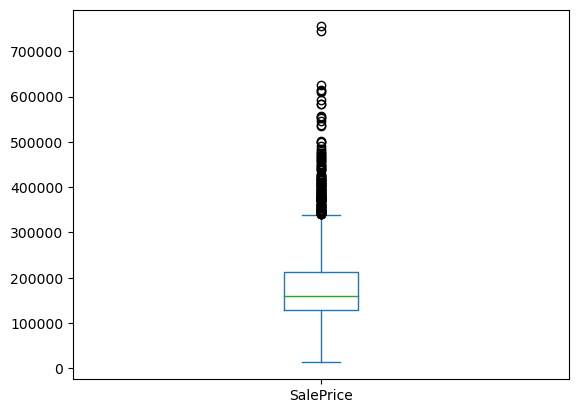

In [66]:
df['SalePrice'].plot.box()


## 6) Errores y duplicados

Errores típicos:
- Registros repetidos.
- Variables mal tipadas.

Técnicas:
- duplicated() para filas duplicadas.
- drop_duplicates() para limpiar.

**👉Contar duplicados en el dataset. Limpiarlos y verificar la diferencia en el número de registros.**


## 7) Normalización y validación de formatos

**Normalización**: dar un formato uniforme a fechas, strings, categorías.

Validación de formatos:
- Fechas como datetime.
- Variables categóricas como category.
- Variables numéricas como int o float.

**Convertir YrSold a tipo fecha.**
- pd.to_datetime( df[Columna], format="%Y")